# 类别数据的处理

In [12]:
import pandas as pd

# 原始数据（假设存在 "未知" 类别）
data = pd.Series(["男", "女", "男", "女", "男", "未知"])
print("原始数据:\n", data)

# 直接生成 One-Hot 编码
one_hot = pd.get_dummies(data, prefix='性别', dtype=int)

print("\nOne-Hot 编码:\n", one_hot)

原始数据:
 0     男
1     女
2     男
3     女
4     男
5    未知
dtype: object

One-Hot 编码:
    性别_女  性别_未知  性别_男
0     0      0     1
1     1      0     0
2     0      0     1
3     1      0     0
4     0      0     1
5     0      1     0


# 日期、时间数据的读取与处理

In [2]:
import locale
locale.setlocale(locale.LC_ALL, 'zh_CN.UTF-8')  # 设置全局本地化

# 安装必要库（首次运行需执行）
# pip install pandas chinese_calendar

import pandas as pd
import chinese_calendar as cal
from chinese_calendar import is_holiday, is_workday

# 读取CSV文件（假设日期列名为'date'）
df = pd.read_csv("datatime.csv", encoding='GBK', parse_dates=['date'])
print(df)

df['date_new'] = pd.to_datetime(df['date'], format='%Y年%m月%d日', errors='coerce')

# 日期特征计算
df = df.assign(
    Year        = df['date_new'].dt.year,
    Month       = df['date_new'].dt.month,
    Day         = df['date_new'].dt.day,
    Quarter     = df['date_new'].dt.quarter,
    DayOfWeek   = df['date_new'].dt.dayofweek,
    DayName     = df['date_new'].dt.day_name(locale='zh_CN.UTF-8'),
    day_of_year = df['date_new'].dt.dayofyear, # 年中的第几天
    is_holiday  = df['date_new'].map(lambda d: is_holiday(d.date())), # 是否节假日（直接调用库函数）
)

# 输出结果
print(df[['date', 'date_new', 'Year', 'Month', 'Day', 'Quarter', 'DayOfWeek', 'DayName', 'day_of_year', 'is_holiday']])

C:\Users\magicbook-2\AppData\Local\Temp\ipykernel_16376\1803204599.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("datatime.csv", encoding='GBK', parse_dates=['date'])


           date
0     2025年1月1日
1     2025年1月2日
2     2025年1月3日
3     2025年1月4日
4     2025年1月5日
..          ...
135  2025年5月16日
136  2025年5月17日
137  2025年5月18日
138  2025年5月19日
139  2025年5月20日

[140 rows x 1 columns]
           date   date_new  Year  Month  Day  Quarter  DayOfWeek DayName  \
0     2025年1月1日 2025-01-01  2025      1    1        1          2     星期三   
1     2025年1月2日 2025-01-02  2025      1    2        1          3     星期四   
2     2025年1月3日 2025-01-03  2025      1    3        1          4     星期五   
3     2025年1月4日 2025-01-04  2025      1    4        1          5     星期六   
4     2025年1月5日 2025-01-05  2025      1    5        1          6     星期日   
..          ...        ...   ...    ...  ...      ...        ...     ...   
135  2025年5月16日 2025-05-16  2025      5   16        2          4     星期五   
136  2025年5月17日 2025-05-17  2025      5   17        2          5     星期六   
137  2025年5月18日 2025-05-18  2025      5   18        2          6     星期日   
138  2025年5月19日 2025-05-

# 图片的读取

(920, 690, 3) (690, 690, 3)
cat = 
 [[[220 219 215]
  [220 219 215]
  [220 219 215]
  ...
  [175 163 151]
  [176 164 150]
  [176 164 150]]

 [[220 219 215]
  [220 219 215]
  [220 219 215]
  ...
  [175 163 151]
  [170 158 144]
  [170 158 144]]

 [[220 219 215]
  [220 219 215]
  [220 219 215]
  ...
  [174 162 150]
  [172 160 146]
  [172 160 146]]

 ...

 [[  7   7   7]
  [  8   8   8]
  [  8   8   8]
  ...
  [ 81  74  66]
  [ 80  71  62]
  [ 78  69  60]]

 [[  7   7   7]
  [  7   7   7]
  [  8   8   8]
  ...
  [ 84  75  66]
  [ 86  77  68]
  [ 84  75  66]]

 [[  8   8   8]
  [  8   8   8]
  [  8   8   8]
  ...
  [ 87  78  69]
  [ 91  82  73]
  [ 89  80  71]]]
dog = 
 [[[  9   9   9]
  [  8   8   8]
  [  7   7   7]
  ...
  [101  61  25]
  [ 98  63  23]
  [ 97  64  21]]

 [[  8   8   8]
  [  7   7   7]
  [  6   6   6]
  ...
  [139 101  65]
  [122  87  47]
  [121  88  45]]

 [[  5   5   5]
  [  5   5   5]
  [  7   7   7]
  ...
  [175 139 105]
  [160 125  87]
  [160 125  85]]

 ...

 [[227 2

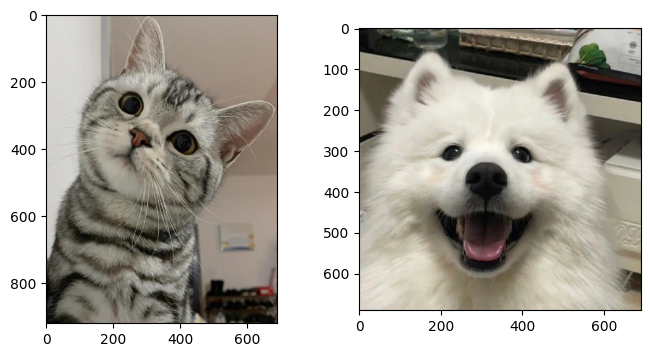

In [4]:
import skimage # 安装 scikit-image
# import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import io
%matplotlib inline

cat = io.imread('./datasets/cat.jpg')
dog = io.imread('./datasets/dog.jpg')
df = pd.DataFrame(['Cat', 'Dog'], columns=['Image'])

print(cat.shape, dog.shape) # RGB,0-255
print("cat = \n",cat)
print("dog = \n", dog)

#coffee = skimage.transform.resize(coffee, (300, 451), mode='reflect')
fig = plt.figure(figsize = (8,4))
ax1 = fig.add_subplot(1,2, 1)
ax1.imshow(cat)
ax2 = fig.add_subplot(1,2, 2)
ax2.imshow(dog)

# 文本内容的读取

In [10]:
from sklearn.datasets import load_files
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

categories = ['alt.atheism', 'comp.graphics', 'misc.forsale', 'sci.space']
train_path = '20news-bydate-train'

dataset_train = load_files(container_path = train_path, categories = categories)

# 数据准备与理解
# 计算词频
count_vect = CountVectorizer(stop_words = 'english', decode_error = 'ignore')
X_train_counts = count_vect.fit_transform(dataset_train.data) # 查看数据维度
print(X_train_counts.shape)

feature_names_0 = count_vect.get_feature_names_out()
df_countvect= pd.DataFrame(X_train_counts.toarray(), columns = feature_names)
print(df_countvect.head())



# 计算TF-IDF
tf_transformer = TfidfVectorizer(stop_words = 'english', decode_error = 'ignore')
X_train_counts_tf = tf_transformer.fit_transform(dataset_train.data)
print(X_train_counts_tf.shape) # 查看数据维度

feature_names_1 = tf_transformer.get_feature_names_out()
df_tfidf = pd.DataFrame(X_train_counts_tf.toarray(), columns = feature_names)
print(df_tfidf.head())

(16, 1368)
   00  001940  02  10  100  100ns  104739  11847  11853  12  ...  years  yes  \
0   0       0   0   0    0      0       0      0      0   0  ...      0    2   
1   0       0   0   0    0      0       0      0      0   0  ...      0    0   
2   0       0   0   0    0      0       0      0      0   0  ...      0    0   
3   0       0   0   0    0      0       0      0      0   0  ...      0    0   
4   0       0   0   0    0      0       0      0      0   0  ...      0    0   

   zealand  zenith  zero  zone  zoo  zoology  zooming  zurich  
0        0       0     0     0    0        0        0       0  
1        0       0     0     0    0        0        0       1  
2        0       0     0     0    0        0        0       0  
3        0       0     1     0    0        0        0       0  
4        0       0     0     0    0        0        0       0  

[5 rows x 1368 columns]
(16, 1368)
    00  001940   02   10  100  100ns  104739  11847  11853   12  ...  years  \
0  0.0   